In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
stocks = [
    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "INFY.NS",
    "ICICIBANK.NS",
    "ITC.NS",
    "SBIN.NS",
    "AXISBANK.NS",
    "KOTAKBANK.NS"
]


stock_data = yf.download(
    stocks,
    start="2020-01-01",
    end="2025-01-01",
    group_by='ticker',
    threads=False
)

[*********************100%***********************]  9 of 9 completed


In [4]:
nifty_data = yf.download(
    "^NSEI",  
    start="2020-01-01",
    end="2025-01-01",
    progress=False
)

print(nifty_data.head())

Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2020-01-01  12182.500000  12222.200195  12165.299805  12202.150391  304100
2020-01-02  12282.200195  12289.900391  12195.250000  12198.549805  407700
2020-01-03  12226.650391  12265.599609  12191.349609  12261.099609  428800
2020-01-06  11993.049805  12179.099609  11974.200195  12170.599609  396500
2020-01-07  12052.950195  12152.150391  12005.349609  12079.099609  447800


In [5]:
close_prices = pd.DataFrame()

for stock in stocks:
    temp = stock_data[stock]['Close'].reset_index()
    temp.columns = ['Date', stock]
    
    if close_prices.empty:
        close_prices = temp
    else:
        close_prices = pd.merge(close_prices, temp, on='Date')

In [6]:
nifty_close = nifty_data[['Close']].reset_index()
nifty_close.columns = ['Date', 'NIFTY50']

In [7]:
final_data = pd.merge(close_prices, nifty_close, on='Date')

In [8]:
print(final_data.head())
print(final_data.shape)
print(final_data.isnull().sum())

        Date  RELIANCE.NS       TCS.NS  HDFCBANK.NS     INFY.NS  ICICIBANK.NS  \
0 2020-01-01   675.324158  1866.113770   605.529358  633.151062    519.137939   
1 2020-01-02   686.821228  1857.546997   609.389160  631.303650    522.861572   
2 2020-01-03   687.648804  1894.566772   600.698792  641.013367    521.169067   
3 2020-01-06   671.700745  1894.394897   587.698792  634.869629    508.450531   
4 2020-01-07   682.034546  1899.043823   597.004822  625.460693    505.742401   

       ITC.NS     SBIN.NS  AXISBANK.NS  KOTAKBANK.NS       NIFTY50  
0  173.395218  308.602600   745.586853    333.417053  12182.500000  
1  174.669617  313.077698   753.802612    332.919128  12282.200195  
2  173.686508  307.910522   739.860840    330.041168  12226.650391  
3  171.210480  294.346588   720.242737    329.134979  11993.049805  
4  171.392532  293.792938   722.732361    332.779755  12052.950195  
(1237, 11)
Date            0
RELIANCE.NS     0
TCS.NS          0
HDFCBANK.NS     0
INFY.NS         

In [9]:
final_data.to_csv("financial_data.csv", index=False)

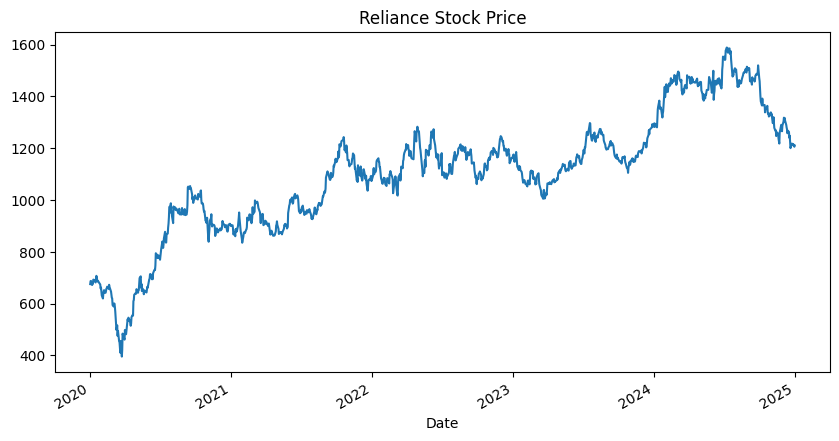

In [10]:
final_data.set_index("Date")["RELIANCE.NS"].plot(figsize=(10,5))
plt.title("Reliance Stock Price")
plt.show()

In [11]:
from sqlalchemy import create_engine
import pandas as pd

# Connection string
engine = create_engine(
    "mssql+pyodbc://MJ9797\\MEET9797/Finance_Project?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

# Load data
df = pd.read_sql("""
SELECT Date, stock_name, daily_return
FROM clean_fact_returns
""", engine)

df.head()

,Date,stock_name,daily_return
0,2020-01-02,AXISBANK.NS,0.011019
1,2020-01-03,AXISBANK.NS,-0.018495
2,2020-01-06,AXISBANK.NS,-0.026516
3,2020-01-07,AXISBANK.NS,0.003457
4,2020-01-08,AXISBANK.NS,-0.001722


In [12]:
df['stock_name'].value_counts()

stock_name
AXISBANK.NS     1236
HDFCBANK.NS     1236
ICICIBANK.NS    1236
INFY.NS         1236
ITC.NS          1236
KOTAKBANK.NS    1236
NIFTY50         1236
RELIANCE.NS     1236
SBIN.NS         1236
TCS.NS          1236
Name: count, dtype: int64

In [13]:
pivot_df = df.pivot(index="Date", columns="stock_name", values="daily_return").sort_index()

# Replace invalid values
pivot_df = pivot_df.replace([np.inf, -np.inf], np.nan)

# Drop weak stocks (less than 90% data)
pivot_df = pivot_df.dropna(axis=1, thresh=int(0.9 * len(pivot_df)))

# Remove index benchmark
if 'NIFTY50' in pivot_df.columns:
    pivot_df = pivot_df.drop(columns=['NIFTY50'])

# Final clean
pivot_df = pivot_df.dropna()

In [14]:
print("📊 Data Check")

print("Shape:", pivot_df.shape)

print("Total NaN values:", pivot_df.isna().sum().sum())
print("Any Inf values:", np.isinf(pivot_df.values).any())

# Data coverage per stock
coverage = pivot_df.notna().mean().sort_values(ascending=False)
print("\n📈 Data Coverage (%):\n", (coverage * 100).round(2))

# Outlier check
print("\n⚠️ Max return:", pivot_df.max().max())
print("⚠️ Min return:", pivot_df.min().min())

# Summary statistics
print("\n📊 Summary Stats:")
print(pivot_df.describe().T)

📊 Data Check
Shape: (1236, 9)
Total NaN values: 0
Any Inf values: False

📈 Data Coverage (%):
 stock_name
AXISBANK.NS     100.0
HDFCBANK.NS     100.0
ICICIBANK.NS    100.0
INFY.NS         100.0
ITC.NS          100.0
KOTAKBANK.NS    100.0
RELIANCE.NS     100.0
SBIN.NS         100.0
TCS.NS          100.0
dtype: float64

⚠️ Max return: 0.19480717709710843
⚠️ Min return: -0.2791077756346518

📊 Summary Stats:
               count      mean       std       min       25%       50%  \
stock_name                                                               
AXISBANK.NS   1236.0  0.000559  0.023078 -0.279108 -0.009289  0.000704   
HDFCBANK.NS   1236.0  0.000446  0.017193 -0.126069 -0.007664  0.000622   
ICICIBANK.NS  1236.0  0.000927  0.020005 -0.178478 -0.007897  0.001163   
INFY.NS       1236.0  0.001011  0.017551 -0.100393 -0.008315  0.000910   
ITC.NS        1236.0  0.000889  0.016302 -0.120798 -0.006609  0.000389   
KOTAKBANK.NS  1236.0  0.000227  0.018520 -0.129996 -0.008691  0.000260   


In [15]:
# Ensure numeric stability
returns = pivot_df.copy()

trading_days = 252

# ✅ Safety fallback
if 'predicted_returns' not in globals():
    print("⚠️ predicted_returns not found, using fallback")
    predicted_returns = returns.mean()

# Convert predicted scalar into stock-wise returns
predicted_mean = predicted_returns.mean() * trading_days

# Historical distribution
historical_mean = returns.mean() * trading_days

mean_returns = historical_mean * (predicted_mean / historical_mean.mean())

# Covariance
cov_matrix = returns.cov() * trading_days

# Risk metrics
volatility = returns.std() * np.sqrt(trading_days)

risk_free_rate = 0.06
individual_sharpe = (mean_returns - risk_free_rate) / volatility

# Display
metrics_df = pd.DataFrame({
    "Return": mean_returns,
    "Volatility": volatility,
    "Sharpe": individual_sharpe
}).sort_values(by="Sharpe", ascending=False)

print(metrics_df)

⚠️ predicted_returns not found, using fallback
                Return  Volatility    Sharpe
stock_name                                  
INFY.NS       0.254810    0.278617  0.699204
ITC.NS        0.224021    0.258784  0.633815
SBIN.NS       0.243947    0.330815  0.556042
ICICIBANK.NS  0.233525    0.317566  0.546421
TCS.NS        0.179555    0.244788  0.488403
RELIANCE.NS   0.163108    0.297418  0.346678
AXISBANK.NS   0.140991    0.366355  0.221073
HDFCBANK.NS   0.112320    0.272926  0.191701
KOTAKBANK.NS  0.057175    0.293992 -0.009609


In [16]:
# Quick sanity validation (light check)
if pivot_df.isna().sum().sum() == 0 and not np.isinf(pivot_df.values).any():
    print("✅ Data is clean and ready for modeling")
else:
    print("❌ Data issues detected")

✅ Data is clean and ready for modeling


In [17]:
num_portfolios = 50000
num_assets = len(mean_returns)

results = np.zeros((5, num_portfolios))
weights_record = []

np.random.seed(42)

for i in range(num_portfolios):

    weights = np.random.random(num_assets)
    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.dot(weights, mean_returns)

    portfolio_volatility = np.sqrt(
        np.dot(weights.T, np.dot(cov_matrix, weights))
    )

    sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility

    # Sortino Ratio
    downside_returns = returns.copy()
    downside_returns[downside_returns > 0] = 0

    downside_std = downside_returns.std() * np.sqrt(252)
    sortino = (portfolio_return - risk_free_rate) / downside_std.mean()

    # Max Drawdown
    portfolio_series = (returns @ weights)
    cumulative = (1 + portfolio_series).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = sharpe
    results[3, i] = sortino
    results[4, i] = max_drawdown

In [18]:
df_results = pd.DataFrame({
    "Return": results[0],
    "Risk": results[1],
    "Sharpe": results[2],
    "Sortino": results[3],
    "Max_Drawdown": results[4]
})

# 🔥 CRITICAL: keep original index BEFORE cleaning
df_results["Portfolio_Index"] = df_results.index

# Clean invalid values
df_results = df_results.replace([np.inf, -np.inf], np.nan).dropna()

# Reset index AFTER cleaning (but keep mapping safe)
df_results = df_results.reset_index(drop=True)

# Ranking
df_results["Sharpe Rank"] = df_results["Sharpe"].rank(ascending=False)
df_results["Sortino Rank"] = df_results["Sortino"].rank(ascending=False)
df_results["Risk Rank"] = df_results["Risk"].rank()

In [19]:
print(df_results.head())

     Return      Risk    Sharpe   Sortino  Max_Drawdown  Portfolio_Index  \
0  0.190429  0.220587  0.591280  0.713214     -0.403322                0   
1  0.202429  0.225944  0.630370  0.778831     -0.418631                1   
2  0.184730  0.230082  0.542110  0.682050     -0.430504                2   
3  0.186921  0.211616  0.599771  0.694031     -0.397453                3   
4  0.195857  0.233636  0.581488  0.742895     -0.414185                4   

   Sharpe Rank  Sortino Rank  Risk Rank  
0      16120.0        9052.0    39741.0  
1       7533.0        1709.0    44948.0  
2      30418.0       16122.0    47210.0  
3      13942.0       13161.0    24594.0  
4      18807.0        4591.0    48421.0  


In [19]:
# Sort by risk
df_results = df_results.sort_values(by="Risk").reset_index(drop=True)

# Efficient Frontier (vectorized)
df_results["Max_Return_So_Far"] = df_results["Return"].cummax()

efficient_frontier = df_results[
    df_results["Return"] == df_results["Max_Return_So_Far"]
].copy()

efficient_frontier = efficient_frontier.drop(columns=["Max_Return_So_Far"])

# Keep best Sharpe per risk bucket
efficient_frontier = efficient_frontier.sort_values(by="Risk")

efficient_frontier = efficient_frontier.loc[
    efficient_frontier.groupby(efficient_frontier["Risk"].round(4))["Sharpe"].idxmax()
]

# Prepare smoothing
x = efficient_frontier["Risk"].values
y = efficient_frontier["Return"].values

# Ensure sorted
sorted_idx = np.argsort(x)
x = x[sorted_idx]
y = y[sorted_idx]

# Smooth curve
from scipy.signal import savgol_filter

window = min(len(y) if len(y) % 2 != 0 else len(y)-1, 11)

if window < 5:
    y_smooth = y
else:
    y_smooth = savgol_filter(y, window, 2)

In [20]:
from scipy.signal import savgol_filter

x = efficient_frontier["Risk"].values
y = efficient_frontier["Return"].values

# Ensure sorted (critical)
sorted_idx = np.argsort(x)
x = x[sorted_idx]
y = y[sorted_idx]

# Dynamic odd window
window = min(11, len(y) if len(y) % 2 != 0 else len(y) - 1)

# Safe smoothing
if window < 5:
    y_smooth = y
else:
    y_smooth = savgol_filter(y, window, 2)

In [21]:
efficient_frontier = efficient_frontier.loc[
    efficient_frontier.groupby(efficient_frontier["Risk"].round(5))["Sharpe"].idxmax()
]

In [22]:
efficient_frontier = efficient_frontier.sort_values(by="Risk").reset_index(drop=True)

# Sanity check
if not efficient_frontier["Risk"].is_monotonic_increasing:
    print("⚠️ Warning: Risk is not strictly increasing")

In [23]:
# Best portfolios based on cleaned results
max_sharpe_idx = df_results["Sharpe"].idxmax()
min_vol_idx = df_results["Risk"].idxmin()
max_sortino_idx = df_results["Sortino"].idxmax()

# Map back to weights
max_sharpe_weights = weights_record[int(df_results.loc[max_sharpe_idx, "Portfolio_Index"])]
min_vol_weights = weights_record[int(df_results.loc[min_vol_idx, "Portfolio_Index"])]
max_sortino_weights = weights_record[int(df_results.loc[max_sortino_idx, "Portfolio_Index"])]

# Display metrics
print("📊 Best Portfolio Metrics:\n")

print("Max Sharpe:\n", df_results.loc[max_sharpe_idx])
print("\nMin Volatility:\n", df_results.loc[min_vol_idx])
print("\nMax Sortino:\n", df_results.loc[max_sortino_idx])

📊 Best Portfolio Metrics:

Max Sharpe:
 Return                   0.227504
Risk                     0.205708
Sharpe                   0.814277
Sortino                  0.915946
Max_Drawdown            -0.379250
Portfolio_Index      32876.000000
Sharpe Rank              1.000000
Sortino Rank             2.000000
Risk Rank            12952.000000
Max_Return_So_Far        0.227504
Name: 12951, dtype: float64

Min Volatility:
 Return                   0.183885
Risk                     0.186355
Sharpe                   0.664779
Sortino                  0.677429
Max_Drawdown            -0.328068
Portfolio_Index      20033.000000
Sharpe Rank           3041.000000
Sortino Rank         17308.000000
Risk Rank                1.000000
Max_Return_So_Far        0.183885
Name: 0, dtype: float64

Max Sortino:
 Return                   0.231746
Risk                     0.215440
Sharpe                   0.797189
Sortino                  0.939145
Max_Drawdown            -0.392038
Portfolio_Index      4880

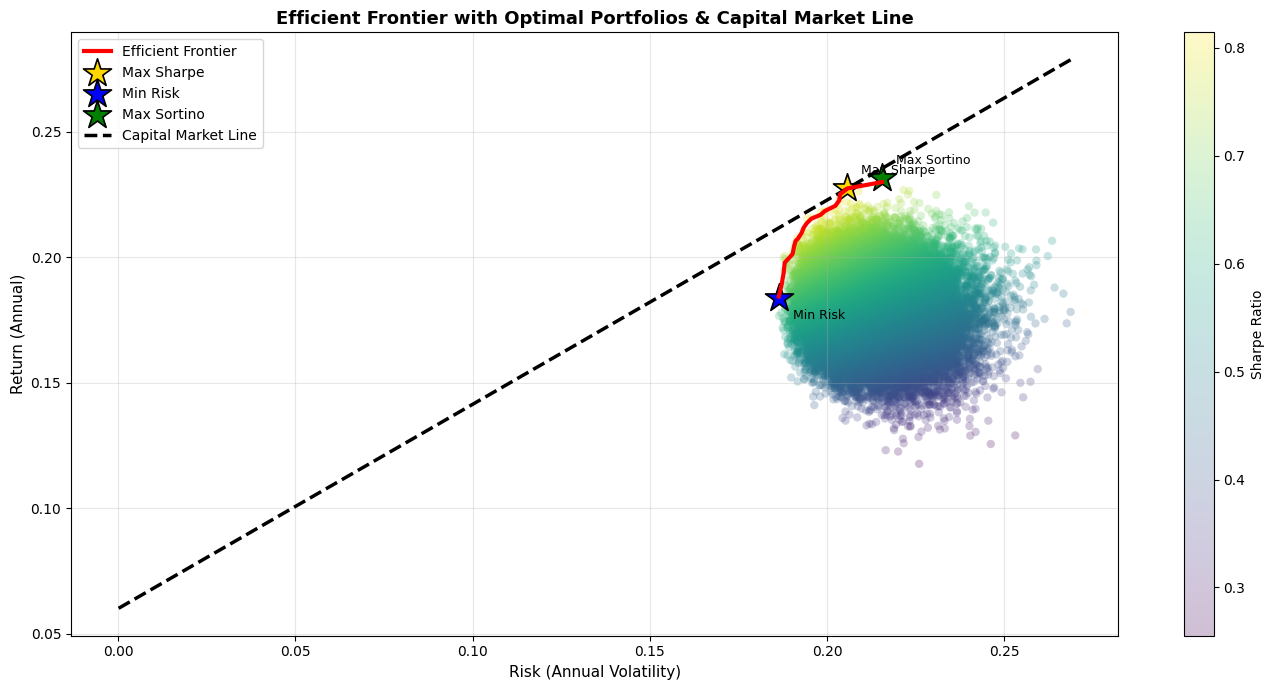

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

# 🔹 Scatter plot (Sharpe colored)
scatter = plt.scatter(
    df_results["Risk"],
    df_results["Return"],
    c=df_results["Sharpe"],
    cmap='viridis',
    alpha=0.25,
    edgecolors='none'
)

cbar = plt.colorbar(scatter)
cbar.set_label("Sharpe Ratio")

# 🔹 Efficient Frontier (highlighted)
plt.plot(
    x, y_smooth,
    color='red',
    linewidth=3,
    zorder=5,
    label="Efficient Frontier"
)

# 🔹 Key portfolios
plt.scatter(
    df_results.loc[max_sharpe_idx, "Risk"],
    df_results.loc[max_sharpe_idx, "Return"],
    color='gold', marker='*', s=450,
    edgecolor='black', linewidth=1.2,
    label='Max Sharpe'
)

plt.scatter(
    df_results.loc[min_vol_idx, "Risk"],
    df_results.loc[min_vol_idx, "Return"],
    color='blue', marker='*', s=450,
    edgecolor='black', linewidth=1.2,
    label='Min Risk'
)

plt.scatter(
    df_results.loc[max_sortino_idx, "Risk"],
    df_results.loc[max_sortino_idx, "Return"],
    color='green', marker='*', s=450,
    edgecolor='black', linewidth=1.2,
    label='Max Sortino'
)

# 🔹 Capital Market Line (CML)
cml_x = np.linspace(0.0001, df_results["Risk"].max(), 100)

cml_y = risk_free_rate + (
    (df_results.loc[max_sharpe_idx, "Return"] - risk_free_rate) /
    df_results.loc[max_sharpe_idx, "Risk"]
) * cml_x

plt.plot(
    cml_x, cml_y,
    linestyle='--',
    linewidth=2.5,
    color='black',
    label='Capital Market Line'
)

# 🔹 Annotations
plt.annotate(
    "Max Sharpe",
    (df_results.loc[max_sharpe_idx, "Risk"],
     df_results.loc[max_sharpe_idx, "Return"]),
    xytext=(10,10),
    textcoords='offset points',
    fontsize=9
)

plt.annotate(
    "Min Risk",
    (df_results.loc[min_vol_idx, "Risk"],
     df_results.loc[min_vol_idx, "Return"]),
    xytext=(10,-15),
    textcoords='offset points',
    fontsize=9
)

plt.annotate(
    "Max Sortino",
    (df_results.loc[max_sortino_idx, "Risk"],
     df_results.loc[max_sortino_idx, "Return"]),
    xytext=(10,10),
    textcoords='offset points',
    fontsize=9
)

# 🔹 Labels & styling
plt.xlabel("Risk (Annual Volatility)", fontsize=11)
plt.ylabel("Return (Annual)", fontsize=11)

plt.title(
    "Efficient Frontier with Optimal Portfolios & Capital Market Line",
    fontsize=13,
    fontweight='bold'
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
portfolio = pd.DataFrame({
    "Stock": pivot_df.columns,
    "Max Sharpe": max_sharpe_weights,
    "Min Risk": min_vol_weights,
    "Max Sortino": max_sortino_weights
})

# Convert to %
portfolio["Max Sharpe %"] = portfolio["Max Sharpe"] * 100
portfolio["Min Risk %"] = portfolio["Min Risk"] * 100
portfolio["Max Sortino %"] = portfolio["Max Sortino"] * 100

# Rank stocks
portfolio["Sharpe Rank"] = portfolio["Max Sharpe"].rank(ascending=False)

# Sort
portfolio = portfolio.sort_values(by="Max Sharpe", ascending=False).reset_index(drop=True)

# Filter meaningful allocations
portfolio_filtered = portfolio[portfolio["Max Sharpe %"] > 1]

print("📊 Full Portfolio:\n", portfolio)
print("\n🔥 Key Allocations (>1%):\n", portfolio_filtered)

📊 Full Portfolio:
           Stock  Max Sharpe  Min Risk  Max Sortino  Max Sharpe %  Min Risk %  \
0       INFY.NS    0.321844  0.187551     0.281000     32.184398   18.755126   
1  ICICIBANK.NS    0.262609  0.008205     0.187063     26.260934    0.820509   
2        ITC.NS    0.231690  0.231155     0.216391     23.169029   23.115463   
3        TCS.NS    0.066261  0.279597     0.002987      6.626119   27.959657   
4   RELIANCE.NS    0.049541  0.057094     0.007471      4.954071    5.709366   
5       SBIN.NS    0.033402  0.012466     0.253047      3.340185    1.246576   
6   HDFCBANK.NS    0.022347  0.124375     0.027621      2.234665   12.437549   
7   AXISBANK.NS    0.011037  0.002107     0.000009      1.103728    0.210725   
8  KOTAKBANK.NS    0.001269  0.097450     0.024411      0.126871    9.745028   

   Max Sortino %  Sharpe Rank  
0      28.099967          1.0  
1      18.706300          2.0  
2      21.639129          3.0  
3       0.298729          4.0  
4       0.747133    

In [26]:
# Create lag features
df_ml = returns.copy()

# Lag returns
for lag in [1, 2, 3, 5]:
    df_ml[f"lag_{lag}"] = df_ml.mean(axis=1).shift(lag)

# Rolling features
df_ml["rolling_mean_5"] = df_ml.mean(axis=1).rolling(5).mean()
df_ml["rolling_std_5"] = df_ml.mean(axis=1).rolling(5).std()

# Target = next day return
df_ml["target"] = df_ml.mean(axis=1).shift(-1)

# Drop NaN
df_ml = df_ml.dropna()

df_ml.head()

stock_name,AXISBANK.NS,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,RELIANCE.NS,SBIN.NS,TCS.NS,lag_1,lag_2,lag_3,lag_5,rolling_mean_5,rolling_std_5,target
Date,,,,,,,,,,,,,,,,
2020-01-09,0.025328,0.011215,0.038692,0.013019,0.006832,0.006164,0.023031,0.032520,-0.018136,-0.000779,0.000874,-0.014890,0.006049,-0.001647,0.008660,0.003804
2020-01-10,-0.003769,0.008888,-0.011075,0.014569,0.009330,0.011801,-0.000226,0.006208,-0.000361,0.015407,-0.000399,0.000575,-0.002421,-0.000416,0.008950,0.002902
2020-01-13,-0.003581,0.002573,-0.003054,0.047958,0.005252,0.003799,-0.002552,-0.004515,-0.010481,0.003929,0.013789,-0.001906,-0.014890,0.003120,0.004089,0.003079
2020-01-14,0.014239,0.002722,-0.001857,0.002715,0.016719,-0.008456,-0.009263,-0.008314,0.007556,0.003933,0.005077,0.012614,0.001031,0.003510,0.003958,-0.000996
2020-01-15,-0.002139,-0.004071,-0.003720,-0.010443,-0.003494,-0.000716,-0.003629,-0.011433,0.009062,0.001784,0.003933,0.004579,-0.001949,0.003558,0.003745,0.002049


In [27]:
from sklearn.model_selection import train_test_split

X = df_ml.drop(columns=["target"])
y = df_ml["target"]

# Time series split (IMPORTANT)
split = int(len(df_ml) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [29]:
predictions = model.predict(X_test)

# Convert to series
predicted_returns = pd.Series(predictions, index=X_test.index)

predicted_returns.head()

Date
2023-12-29    0.000817
2024-01-01    0.001271
2024-01-02    0.000418
2024-01-03    0.000329
2024-01-04   -0.000075
dtype: float64

In [30]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)

print("📊 Model MSE:", mse)

# Correlation check (VERY IMPORTANT)
correlation = np.corrcoef(y_test, predictions)[0,1]
print("📈 Prediction Correlation:", correlation)

📊 Model MSE: 3.0498878908251898e-05
📈 Prediction Correlation: -0.009135496256080788


In [31]:
window = 60   # training window (days)
portfolio_returns = []

dates = returns.index

In [32]:
from sklearn.ensemble import RandomForestRegressor

for i in range(window, len(returns)-1):

    # Training data
    train_returns = returns.iloc[i-window:i]

    # Create ML dataset (same logic as before)
    df_ml = train_returns.copy()

    df_ml["mean_return"] = df_ml.mean(axis=1)

    for lag in [1,2,3,5]:
        df_ml[f"lag_{lag}"] = df_ml["mean_return"].shift(lag)

    df_ml["rolling_mean_5"] = df_ml["mean_return"].rolling(5).mean()
    df_ml["rolling_std_5"] = df_ml["mean_return"].rolling(5).std()

    df_ml["target"] = df_ml["mean_return"].shift(-1)

    df_ml = df_ml.dropna()

    if len(df_ml) < 10:
        continue

    X = df_ml.drop(columns=["target"])
    y = df_ml["target"]

    # Train model
    model = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
    model.fit(X, y)

    # Latest features for prediction
    latest = df_ml.drop(columns=["target"]).iloc[-1:]

    pred_return = model.predict(latest)[0]

    # Convert to stock-level expected returns
    historical_mean = train_returns.mean() * 252
    predicted_mean = pred_return * 252

    mean_returns_bt = historical_mean * (predicted_mean / historical_mean.mean())

    cov_matrix_bt = train_returns.cov() * 252

    # Equal weight portfolio (simple but strong baseline)
    weights = np.ones(len(mean_returns_bt)) / len(mean_returns_bt)

    # Next day actual return
    next_day_return = returns.iloc[i+1]

    portfolio_return = np.dot(weights, next_day_return)

    portfolio_returns.append(portfolio_return)

In [33]:
portfolio_returns = pd.Series(portfolio_returns, index=dates[window+1:])

cumulative = (1 + portfolio_returns).cumprod()

In [34]:
# Benchmark (equal weight market proxy)
benchmark_returns = returns.mean(axis=1)

benchmark_returns = benchmark_returns.loc[portfolio_returns.index]

benchmark_cumulative = (1 + benchmark_returns).cumprod()

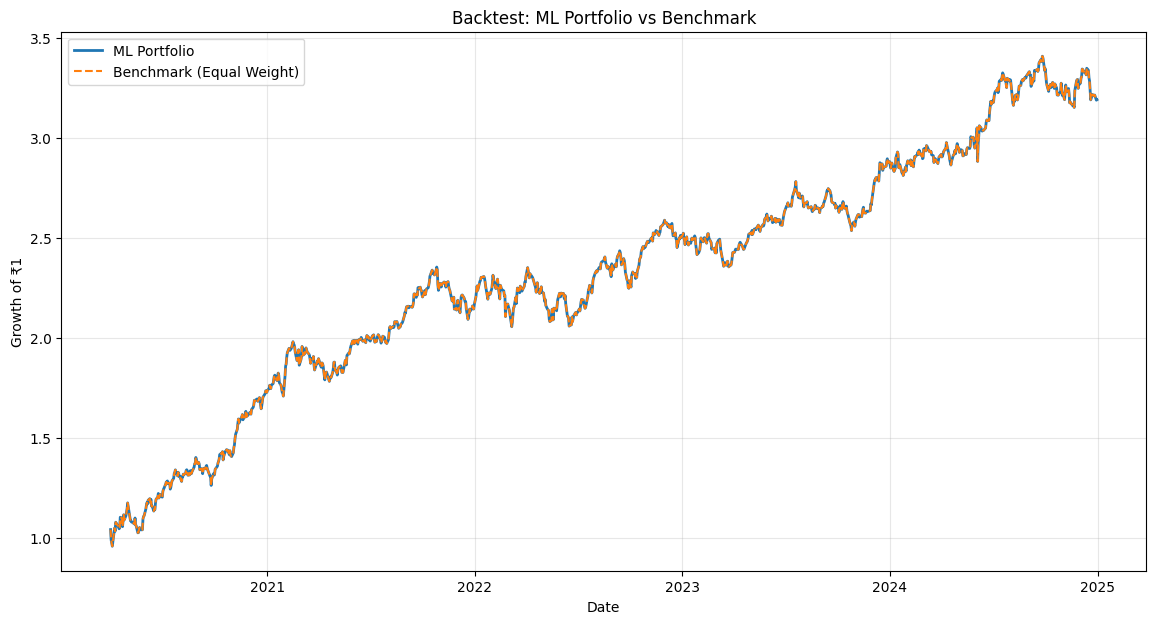

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(cumulative, label="ML Portfolio", linewidth=2)
plt.plot(benchmark_cumulative, label="Benchmark (Equal Weight)", linestyle='--')

plt.title("Backtest: ML Portfolio vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
# CAGR
years = len(portfolio_returns) / 252
cagr = cumulative.iloc[-1] ** (1/years) - 1

# Max Drawdown
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_dd = drawdown.min()

# Sharpe
sharpe = (portfolio_returns.mean() * 252 - risk_free_rate) / (portfolio_returns.std() * np.sqrt(252))

print("📊 Performance Metrics:\n")
print(f"CAGR: {cagr:.2%}")
print(f"Max Drawdown: {max_dd:.2%}")
print(f"Sharpe Ratio: {sharpe:.2f}")

📊 Performance Metrics:

CAGR: 28.27%
Max Drawdown: -12.75%
Sharpe Ratio: 1.14


In [37]:
df_results.to_csv("Portfolio_results.csv", index=False)

In [38]:
portfolio.to_csv("Portfolio_weights.csv", index=False)

In [39]:
pd.DataFrame({
    "Date": cumulative.index,
    "Portfolio": cumulative.values,
    "Benchmark": benchmark_cumulative.values
}).to_csv("Backtest.csv", index=False)

In [40]:
pd.DataFrame({
    "Date": cumulative.index,
    "Drawdown": drawdown.values
}).to_csv("Drawdown.csv", index=False)

In [41]:
import os
print(os.getcwd())

C:\Users\Meet Joshi\Desktop\Projects\main projects\Project 3 Finance Project


In [42]:
kpi_df = pd.DataFrame({
    "Metric": ["CAGR", "Sharpe Ratio", "Max Drawdown", "Final Value"],
    "Value": [cagr, sharpe, max_dd, cumulative.iloc[-1]]
})

kpi_df.to_csv("kpi.csv", index=False)

In [44]:
df_results.to_csv("C:/Users/Meet Joshi/Desktop/Projects/main projects/Project 3 Finance Project/efficient_frontier.csv", index=False)

In [23]:
import pandas as pd
import numpy as np

# Use your existing df_results
df_sorted = df_results.sort_values("Risk").reset_index(drop=True)

# Create bins (reduce points)
df_sorted["Risk_bin"] = pd.cut(df_sorted["Risk"], bins=50)

# Pick BEST return in each risk bucket
frontier = df_sorted.loc[df_sorted.groupby("Risk_bin")["Return"].idxmax()]

# Keep only required columns
frontier = frontier[["Risk", "Return", "Sharpe"]].sort_values("Risk")

# Save clean frontier
frontier.to_csv("efficient_frontier_clean.csv", index=False)

print("✅ Clean Efficient Frontier saved")

✅ Clean Efficient Frontier saved


In [21]:
# Max Sharpe Portfolio
max_sharpe = df_results.loc[df_results["Sharpe"].idxmax()]

# Min Risk Portfolio
min_risk = df_results.loc[df_results["Risk"].idxmin()]

# Max Return Portfolio
max_return = df_results.loc[df_results["Return"].idxmax()]

# Combine
key_df = pd.DataFrame([max_sharpe, min_risk, max_return])

# Add labels
key_df["Type"] = ["Max Sharpe", "Min Risk", "Max Return"]

# Save file
key_df.to_csv(r"C:\Users\Meet Joshi\Desktop\key_points.csv", index=False)

print("✅ key_points.csv saved")

✅ key_points.csv saved


In [22]:
# Add unique ID to frontier
frontier["Portfolio_ID"] = range(1, len(frontier)+1)

# Save again
frontier.to_csv(r"C:\Users\Meet Joshi\Desktop\frontier.csv", index=False)

In [26]:
# Find key points

max_sharpe = df_results.loc[df_results["Sharpe"].idxmax()]
min_risk = df_results.loc[df_results["Risk"].idxmin()]

# Create dataframe
key_points = pd.DataFrame({
    "Type": ["Max Sharpe", "Min Risk"],
    "Risk": [max_sharpe["Risk"], min_risk["Risk"]],
    "Return": [max_sharpe["Return"], min_risk["Return"]],
    "Sharpe": [max_sharpe["Sharpe"], min_risk["Sharpe"]]
})

# Save file
key_points.to_csv("key_pointers.csv", index=False)

print("✅ key_pointers.csv created")

✅ key_pointers.csv created


In [25]:
import os
print(os.getcwd())

C:\Users\Meet Joshi\Desktop\Projects\main projects\Project 3 Finance Project


In [27]:
rf = 0.05  # risk-free rate (5%)

# max sharpe portfolio
max_sharpe = df_results.loc[df_results["Sharpe"].idxmax()]

# generate CML line
risk_range = np.linspace(0, df_results["Risk"].max(), 100)

cml_return = rf + (max_sharpe["Return"] - rf) / max_sharpe["Risk"] * risk_range

cml = pd.DataFrame({
    "Risk": risk_range,
    "Return": cml_return
})

cml.to_csv("cml.csv", index=False)

print("✅ CML created")

✅ CML created


In [28]:
import pandas as pd

# Load your results
df = df_results.copy()

# Sort by Risk
df = df.sort_values("Risk")

# Create bins for smoothing
df["bin"] = pd.cut(df["Risk"], bins=50)

# Take best return per bin (efficient frontier)
frontier = df.groupby("bin").agg({
    "Risk": "mean",
    "Return": "max"
}).reset_index(drop=True)

# Save clean frontier
frontier.to_csv("efc.csv", index=False)

print("✅ Clean frontier saved")

✅ Clean frontier saved


In [29]:
# Sort properly
frontier = frontier.sort_values("Risk").reset_index(drop=True)

# Create index column
frontier["Index"] = range(len(frontier))

# Save again
frontier.to_csv("efc.csv", index=False)

print("✅ Final clean frontier saved")

✅ Final clean frontier saved
